# 요금제 EDA

`data/final/`의 최종 요금제·혜택 CSV를 한 번에 요약하지 않고, 한 항목씩 찍어보면서
다음 phase(페르소나 재정의 -> 합성 유저 데이터)에 쓸 근거를 쌓는다.

컬럼 의미는 `docs/컬럼_명세서.md`에 정리되어 있고, 특히 아래 두 가지를 주의한다.
- 가격 비교는 `monthly_fee`(정가)가 아니라 `discounted_fee`(실제 납부액)로 한다.
- `data_gb`가 비어 있으면 결측이 아니라 무제한이다(`data_unlimited`로 따로 본다).

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# notebooks/ 에서 실행돼도 src/schema.py를 import할 수 있게 경로를 잡는다.
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(BASE_DIR / "src"))
from schema import final_path  # noqa: E402

pd.set_option("display.max_columns", 50)
plans = pd.read_csv(final_path("통신요금제_통합데이터_최종.csv"), encoding="utf-8-sig")
benefits = pd.read_csv(final_path("통신요금제_혜택상세_최종.csv"), encoding="utf-8-sig")
plans.shape, benefits.shape

((2799, 40), (5129, 13))

In [2]:
plans.head(3)

,carrier_type,host_mno,mvno_brand,plan_id,base_plan_id,plan_id_type,plan_name,selected_option,plan_category,is_online_only,age_condition,signup_notice,network_gen,base_data_gb,extra_data_gb,data_gb,data_unlimited,data_throttle_speed,daily_data_gb,base_tethering_gb,extra_tethering_gb,tethering_gb,voice_unlimited,voice_minutes,voice_extra_minutes,sms_unlimited,sms_count,monthly_fee,discounted_fee,discount_type,discount_period_months,benefit_count,ott_option_count,ott_options,membership_grade,smart_device_benefit,extra_data_benefit,gift_benefit,source_url,crawled_at
0,MNO,KT,NaN,1692_초이스 더블 유튜브 프리미엄+넷플릭스,1692_초이스 더블 유튜브 프리미엄+넷플릭스,official_code,초이스 더블 유튜브 프리미엄+넷플릭스,NaN,KT-통합요금제,False,NaN,NaN,5G,NaN,NaN,NaN,True,100Kbps,NaN,90.0,NaN,90.0,True,NaN,300.0,True,NaN,120000,90000.0,선택약정 25% 할인,NaN,10,5,유튜브 프리미엄 | 넷플릭스 | 지니뮤직 | 밀리의서재,VVIP,스마트기기/데이터쉐어링 스마트기기 월정액/ 데이터쉐어링 각 1회선 할인,공유데이터 90GB,쇼핑라운지 할인 쿠폰 (5천원권),https://product.kt.com/wDic/productDetail.do?I...,2026-08-06T00:42:25.106527+00:00
1,MNO,KT,NaN,1692_초이스 더블 유튜브 프리미엄+디바이스,1692_초이스 더블 유튜브 프리미엄+디바이스,official_code,초이스 더블 유튜브 프리미엄+디바이스,NaN,KT-통합요금제,False,NaN,NaN,5G,NaN,NaN,NaN,True,100Kbps,NaN,90.0,NaN,90.0,True,NaN,300.0,True,NaN,120000,90000.0,선택약정 25% 할인,NaN,10,4,유튜브 프리미엄 | 지니뮤직 | 밀리의서재,VVIP,디바이스 할인(최대 6천원) | 스마트기기/데이터쉐어링 스마트기기 월정액/ 데이터쉐...,공유데이터 90GB,쇼핑라운지 할인 쿠폰 (5천원권),https://product.kt.com/wDic/productDetail.do?I...,2026-08-06T00:42:25.106527+00:00
2,MNO,KT,NaN,1692_초이스 더블 디바이스,1692_초이스 더블 디바이스,official_code,초이스 더블 디바이스,NaN,KT-통합요금제,False,NaN,NaN,5G,NaN,NaN,NaN,True,100Kbps,NaN,90.0,NaN,90.0,True,NaN,300.0,True,NaN,120000,90000.0,선택약정 25% 할인,NaN,11,5,지니뮤직 | 밀리의서재,VVIP,디바이스 할인 (1개 or 2개 선택 가능) 1개 선택 시 최대 12천원 할인 2개...,공유데이터 90GB,쇼핑라운지 할인 쿠폰 (5천원권),https://product.kt.com/wDic/productDetail.do?I...,2026-08-06T00:42:25.106527+00:00


## 1. 통신사/유형 분포

In [3]:
plans["carrier_type"].value_counts()

carrier_type
MVNO    2248
MNO      551
Name: count, dtype: int64

In [4]:
plans["host_mno"].value_counts()

host_mno
LGU+    1080
KT      1012
SKT      707
Name: count, dtype: int64

In [5]:
# MVNO만 골라 브랜드 상위 15개 - 알뜰폰 시장이 특정 브랜드에 쏠려 있는지 본다
plans.loc[plans["carrier_type"] == "MVNO", "mvno_brand"].value_counts().head(15)

mvno_brand
티플러스        229
스마텔         177
아이즈모바일      175
프리티         174
이야기모바일      164
모빙          156
SK7모바일      121
고고모바일        88
KT스카이라이프     86
에이모바일        86
이지모바일        83
KG모바일        81
리브모바일        79
더원모바일        77
U+유모바일       61
Name: count, dtype: int64

In [6]:
plans["network_gen"].value_counts()

network_gen
LTE    1745
5G     1054
Name: count, dtype: int64

## 2. 가격 (`discounted_fee` = 실제 납부액, `monthly_fee`는 정가라 비교엔 안 씀)

In [7]:
plans["discounted_fee"].describe()

count     2740.000000
mean     24435.424453
std      23569.573346
min          0.000000
25%       8800.000000
50%      17600.000000
75%      30900.000000
max      97500.000000
Name: discounted_fee, dtype: float64

In [8]:
plans.groupby("carrier_type")["discounted_fee"].describe()

,count,mean,std,min,25%,50%,75%,max
carrier_type,,,,,,,,
MNO,492.0,62543.666667,26036.775904,7000.0,41250.0,67500.0,82500.0,97500.0
MVNO,2248.0,16095.008452,11893.478820,0.0,6600.0,14455.0,23000.0,57200.0


In [9]:
plans.groupby("host_mno")["discounted_fee"].describe()

,count,mean,std,min,25%,50%,75%,max
host_mno,,,,,,,,
KT,999.0,31366.246246,25979.638195,0.0,13750.0,22000.0,41250.0,97500.0
LGU+,1034.0,18471.069632,19033.357147,0.0,5000.0,14000.0,25300.0,97500.0
SKT,707.0,23365.059406,23448.631267,10.0,8015.0,15400.0,29250.0,96750.0


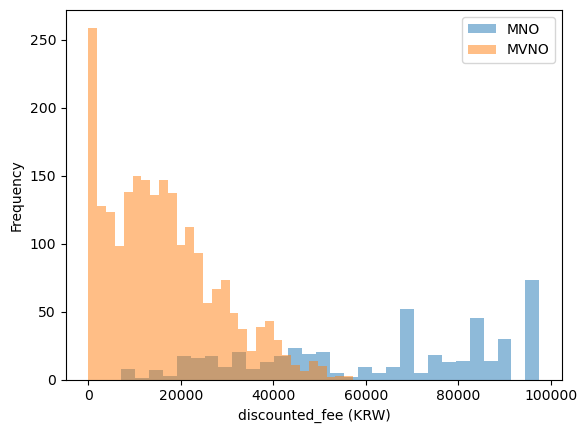

In [10]:
fig, ax = plt.subplots()
for carrier, group in plans.groupby("carrier_type"):
    group["discounted_fee"].dropna().plot(kind="hist", bins=30, alpha=0.5, ax=ax, label=carrier)
ax.set_xlabel("discounted_fee (KRW)")
ax.legend()
plt.show()

## 3. 데이터 제공량 (`data_gb`가 비면 결측이 아니라 무제한 -> `data_unlimited`로 따로 본다)

In [11]:
# carrier_type별 데이터 무제한 비율
plans.groupby("carrier_type")["data_unlimited"].mean()

carrier_type
MNO     0.591652
MVNO    0.003114
Name: data_unlimited, dtype: float64

In [12]:
# 무제한 제외(정량 요금제만) data_gb 분포
metered = plans.loc[~plans["data_unlimited"].fillna(False)]
metered.groupby("carrier_type")["data_gb"].describe()

,count,mean,std,min,25%,50%,75%,max
carrier_type,,,,,,,,
MNO,217.0,44.532488,61.493174,0.244,6.0,15.0,51.0,300.0
MVNO,2168.0,29.805192,43.487146,0.098,7.0,11.0,17.0,250.0


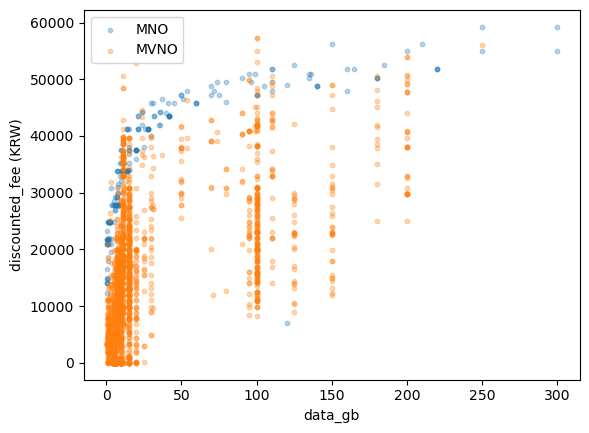

In [13]:
fig, ax = plt.subplots()
for carrier, group in metered.groupby("carrier_type"):
    ax.scatter(group["data_gb"], group["discounted_fee"], alpha=0.3, s=10, label=carrier)
ax.set_xlabel("data_gb")
ax.set_ylabel("discounted_fee (KRW)")
ax.legend()
plt.show()

## 4. 통화·문자 (대부분 무제한일 것으로 예상 - 실제로 얼마나인지 확인)

In [14]:
plans.groupby("carrier_type")[["voice_unlimited", "sms_unlimited"]].mean()

,voice_unlimited,sms_unlimited
carrier_type,,
MNO,0.954628,0.941924
MVNO,0.530249,0.513345


In [15]:
# 음성이 무제한이 아닌 요금제만 - 몇 분이나 주는지 (제한형 요금제의 실제 스펙)
plans.loc[~plans["voice_unlimited"].fillna(False), "voice_minutes"].describe()

count     945.000000
mean      300.696296
std       571.596875
min         2.000000
25%       100.000000
50%       200.000000
75%       300.000000
max      9997.000000
Name: voice_minutes, dtype: float64

## 5. 연령 조건 (`age_condition`, 정규화된 값 - schema.normalize_age_condition 적용 후)

In [16]:
# 일반(연령 무관) 요금제 비율
(plans["age_condition"].fillna("") == "").mean()

np.float64(0.8960342979635584)

In [17]:
plans.loc[plans["age_condition"].fillna("") != "", "age_condition"].value_counts()

age_condition
만 34세 이하    101
만 65세 이상     63
만 18세 이하     58
만 75세 이상     52
만 12세 이하     14
만 70세 이상      1
만 80세 이상      1
현역병사          1
Name: count, dtype: int64

In [18]:
# 연령 조건 요금제가 MNO/MVNO 어느 쪽에 몰려 있는지 - 페르소나의 연령x통신사 선호 조합이
# 실제로 가입 가능한 조합인지 확인하는 목적
restricted = plans.loc[plans["age_condition"].fillna("") != ""]
pd.crosstab(restricted["age_condition"], restricted["carrier_type"])

carrier_type,MNO
age_condition,
만 12세 이하,14
만 18세 이하,58
만 34세 이하,101
만 65세 이상,63
만 70세 이상,1
만 75세 이상,52
만 80세 이상,1
현역병사,1


## 6. 혜택 (요금제 테이블의 요약 컬럼 + benefits.csv 상세)

In [19]:
plans["ott_option_count"].value_counts().sort_index()

ott_option_count
0    2525
1     102
2      13
3      44
4     107
5       8
Name: count, dtype: int64

In [20]:
plans["membership_grade"].value_counts()

membership_grade
VIP     156
VVIP    138
Name: count, dtype: int64

In [21]:
benefits["benefit_category"].value_counts()

benefit_category
사은품/페이백    2613
OTT/구독      728
추가데이터       630
기타          516
스마트기기       348
멤버십         294
Name: count, dtype: int64

In [22]:
# benefit_value_won은 일부만 채워진다(컬럼 명세서 확인됨) - 채움 비율과
# 채워진 값의 분포를 분리해서 봐야 평균을 오독하지 않는다
print("채움 비율:", benefits["benefit_value_won"].notna().mean())
benefits["benefit_value_won"].dropna().describe()

채움 비율: 0.24780658997855332


count      1271.000000
mean      27433.052714
std       42579.924608
min           0.000000
25%        5000.000000
50%       14300.000000
75%       20000.000000
max      360000.000000
Name: benefit_value_won, dtype: float64

## 7. 요금제 개수 (행 수 vs 실제 요금제 수)

In [23]:
# 행 수(택1 전개 포함) vs 실제 요금제 수(base_plan_id 기준)
len(plans), plans["base_plan_id"].nunique()

(2799, 2449)

## 8. 결측/커버리지 종합 (39개 plan + 13개 benefit 컬럼 전체를 한 번에)

지금까지는 컬럼별로 필요할 때만 결측을 확인했다. 어떤 컬럼이 애초에 잘 안 채워지는지
전체를 한 번에 훑어서, 뒤 섹션에서 어느 컬럼을 믿고 어느 컬럼을 조심해야 할지 정한다.

In [24]:
import seaborn as sns

null_rate = pd.concat([
    plans.isna().mean().rename("plans"),
    benefits.isna().mean().rename("benefits"),
])
null_rate = null_rate.sort_values(ascending=False)
null_rate.head(20)

user_pay_won            0.984597
benefit_tier            0.984597
extra_data_gb           0.968203
extra_tethering_gb      0.948196
selected_option         0.920329
ott_options             0.902108
age_condition           0.896034
membership_grade        0.894962
smart_device_benefit    0.893891
daily_data_gb           0.891033
benefit_service         0.848703
extra_data_benefit      0.841015
select_group            0.821213
signup_notice           0.777063
benefit_value_won       0.752193
base_tethering_gb       0.712040
tethering_gb            0.712040
voice_minutes           0.662379
sms_count               0.649160
voice_extra_minutes     0.590211
dtype: float64

C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_21720\3092254421.py:5: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_21720\3092254421.py:5: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_21720\3092254421.py:5: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NT551_11TH\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\NT551_11TH\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\NT551_11TH\anaconda3\Lib\site-packag

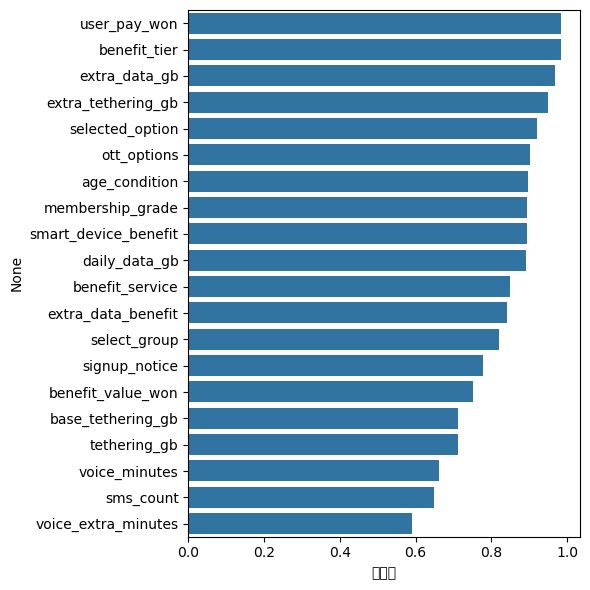

In [25]:
top_null = null_rate[null_rate > 0].head(20)
fig, ax = plt.subplots(figsize=(6, 6))
sns.barplot(x=top_null.values, y=top_null.index, ax=ax)
ax.set_xlabel("결측률")
plt.tight_layout()
plt.show()

## 9. MVNO 브랜드별 가격·데이터 (섹션1은 카운트만 봤음 - 브랜드마다 가격대가 다른지)

In [26]:
# 카운트 상위 10개 브랜드만 (롱테일 브랜드는 표본이 너무 작아 describe가 의미 없음)
top_brands = plans.loc[plans["carrier_type"] == "MVNO", "mvno_brand"].value_counts().head(10).index
mvno_top = plans[plans["mvno_brand"].isin(top_brands)]
mvno_top.groupby("mvno_brand")[["discounted_fee", "data_gb"]].describe()

discounted_fee                                               \
                    count          mean           std     min      25%   
mvno_brand                                                               
KT스카이라이프             86.0  25628.488372  12092.872331     0.0  17675.0   
SK7모바일              121.0  19581.900826  11952.134002  1900.0  10120.0   
고고모바일                88.0  18628.068182  12154.495300    10.0  10972.5   
모빙                  156.0  13325.769231  11179.135291    10.0   4400.0   
스마텔                 177.0  15453.728814  13457.743111    10.0   3000.0   
아이즈모바일              175.0  15354.171429  13495.019059    10.0   5500.0   
에이모바일                86.0  10167.779070   9934.812129    10.0    990.0   
이야기모바일              164.0  15870.975610  10716.155353     0.0   7865.0   
티플러스                229.0  13006.593886   8874.155641    10.0   6600.0   
프리티                 174.0  17019.540230  10655.314548    10.0  10065.0   

                                      data_gb                               \
                50%      75%      max   count       mean        std    min   
mvno_brand                                                                   
KT스카이라이프    24750.0  36300.0  49200.0    85.0  29.426400  42.043268  0.244   
SK7모바일      16900.0  26400.0  50600.0   121.0  18.289058  29.956250  0.488   
고고모바일       16000.0  24090.0  48730.0    85.0  26.517647  33.586283  1.000   
모빙          12000.0  18700.0  47700.0   152.0  30.161184  47.094790  1.000   
스마텔         14000.0  23000.0  53900.0   174.0  21.810345  35.470134  1.000   
아이즈모바일      10500.0  22350.0  57200.0   173.0  24.864162  36.320405  1.000   
에이모바일        8800.0  17975.0  39600.0    82.0  26.603659  39.998900  1.000   
이야기모바일      14300.0  23000.0  49800.0   159.0  25.695673  38.500193  0.488   
티플러스        12000.0  18000.0  30900.0   221.0  23.413122  31.983232  1.000   
프리티         16335.0  22715.0  52800.0   168.0  32.033333  43.803283  1.000   

                                    
            25%   50%   75%    max  
mvno_brand                          
KT스카이라이프    7.0  11.0  15.0  200.0  
SK7모바일      5.0  10.0  15.0  200.0  
고고모바일       7.0  11.0  15.0  110.0  
모빙          7.0  11.0  15.0  200.0  
스마텔         5.0  10.0  15.0  200.0  
아이즈모바일      7.0  11.0  15.0  200.0  
에이모바일       7.0  11.0  15.0  200.0  
이야기모바일      6.0  11.0  20.0  200.0  
티플러스        7.0  11.0  15.0  150.0  
프리티         7.0  15.0  20.0  200.0

C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_21720\1569432376.py:3: UserWarning: Glyph 54000 (\N{HANGUL SYLLABLE TI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_21720\1569432376.py:3: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_21720\1569432376.py:3: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_21720\1569432376.py:3: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_21720\1569432376.py:3: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\NT551_11TH\AppData\Local\Temp\ipykernel_21720\1569432376.py:3: UserWarning: Glyph 53588 (\N{HANGUL SYL

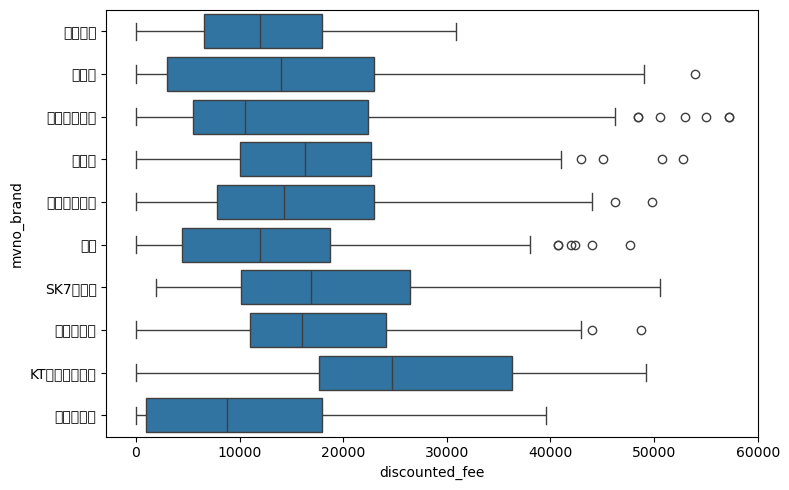

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=mvno_top, x="discounted_fee", y="mvno_brand", order=top_brands, ax=ax)
plt.tight_layout()
plt.show()

## 10. 5G/LTE 교차분석 (섹션1에서 카운트만 봤고 아무 것과도 교차 안 했음)

In [28]:
pd.crosstab(plans["network_gen"], plans["carrier_type"])

carrier_type,MNO,MVNO
network_gen,,
5G,541,513
LTE,10,1735


In [29]:
plans.groupby("network_gen")[["discounted_fee", "data_gb"]].describe()

discounted_fee                                                     \
                     count          mean          std   min      25%      50%   
network_gen                                                                     
5G                   996.0  40974.600402  30030.05567  10.0  15400.0  34100.0   
LTE                 1744.0  14989.885894  10610.73805   0.0   6600.0  14000.0   

                              data_gb                                     \
                 75%      max   count       mean        std    min   25%   
network_gen                                                                
5G           67500.0  97500.0   720.0  56.335140  63.047910  0.244  9.75   
LTE          21462.5  57200.0  1665.0  20.252195  29.470174  0.098  7.00   

                                
              50%   75%    max  
network_gen                     
5G           20.0  95.0  300.0  
LTE          11.0  15.0  100.0

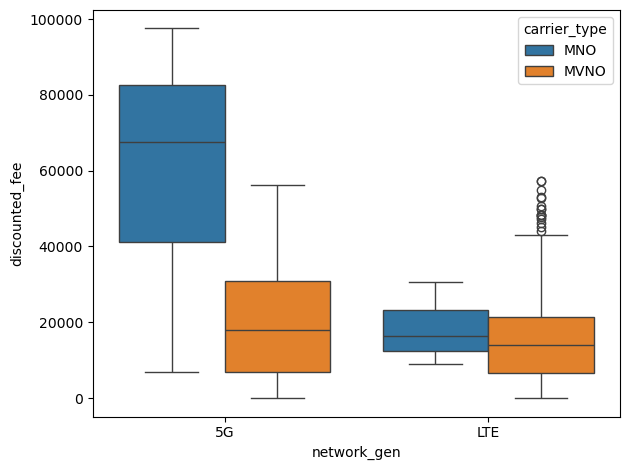

In [30]:
fig, ax = plt.subplots()
sns.boxplot(data=plans, x="network_gen", y="discounted_fee", hue="carrier_type", ax=ax)
plt.tight_layout()
plt.show()

## 11. 테더링 (`base_tethering_gb`/`extra_tethering_gb`/`tethering_gb` - 지금까지 미탐색)

In [31]:
teth_cols = ["base_tethering_gb", "extra_tethering_gb", "tethering_gb"]
plans[teth_cols].isna().mean(), plans[teth_cols].describe()

(base_tethering_gb     0.712040
 extra_tethering_gb    0.948196
 tethering_gb          0.712040
 dtype: float64,
        base_tethering_gb  extra_tethering_gb  tethering_gb
 count         806.000000          145.000000    806.000000
 mean           46.441687           59.034483     57.062035
 std            40.768915           28.298364     55.813044
 min             0.000000           20.000000      0.000000
 25%            10.000000           30.000000     10.000000
 50%            40.000000           60.000000     40.000000
 75%            80.000000           80.000000    100.000000
 max           140.000000          100.000000    200.000000)

In [32]:
# tethering_gb가 채워진 요금제만 - carrier_type/network_gen별로 얼마나 주는지
has_teth = plans.dropna(subset=["tethering_gb"])
pd.crosstab(has_teth["carrier_type"], has_teth["network_gen"])

network_gen,5G,LTE
carrier_type,,
MNO,378,3
MVNO,117,308


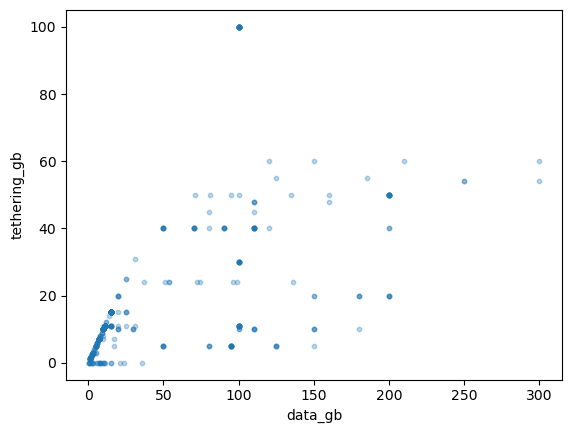

In [33]:
fig, ax = plt.subplots()
ax.scatter(has_teth["data_gb"], has_teth["tethering_gb"], alpha=0.3, s=10)
ax.set_xlabel("data_gb")
ax.set_ylabel("tethering_gb")
plt.show()

## 12. 데이터 소진 후 속도 (`data_throttle_speed` - 지금까지 미탐색)

In [34]:
plans["data_throttle_speed"].value_counts()

data_throttle_speed
1Mbps      725
3Mbps      523
5Mbps      376
100Kbps    116
400Kbps    111
200Kbps     48
10Mbps      39
Name: count, dtype: int64

In [35]:
# data_unlimited 요금제가 소진 후에도 완속으로 계속 되는 건지 - carrier_type과 교차
pd.crosstab(plans["carrier_type"], plans["data_throttle_speed"].notna(), rownames=["carrier_type"], colnames=["has_throttle_speed"])

has_throttle_speed,False,True
carrier_type,,
MNO,203,348
MVNO,658,1590


## 13. 요금 구조 (정가-할인가 갭, `discount_type`, `discount_period_months` - 지금까지 `discounted_fee`만 봤음)

In [36]:
# 정가 대비 실제 납부액이 얼마나 깎이는지 (할인율)
gap = (plans["monthly_fee"] - plans["discounted_fee"]) / plans["monthly_fee"]
gap.describe()

count    2740.000000
mean        0.372514
std         0.315989
min         0.000000
25%         0.000000
50%         0.308000
75%         0.613087
max         1.000000
dtype: float64

In [37]:
plans["discount_type"].value_counts()

discount_type
모요 프로모션 할인        1451
선택약정 25% 할인        447
모요 프로모션 페이백/할인      87
Name: count, dtype: int64

In [38]:
pd.crosstab(plans["discount_type"], plans["carrier_type"])

carrier_type,MNO,MVNO
discount_type,,
모요 프로모션 페이백/할인,2,85
모요 프로모션 할인,0,1451
선택약정 25% 할인,447,0


In [39]:
plans["discount_period_months"].describe()

count    1537.000000
mean       10.512036
std         6.780603
min         4.000000
25%         7.000000
50%         7.000000
75%        12.000000
max        36.000000
Name: discount_period_months, dtype: float64

## 14. 온라인전용/카테고리 (`is_online_only`, `plan_category` - 지금까지 미탐색)

In [40]:
plans.groupby("host_mno")["is_online_only"].mean()

host_mno
KT      0.745059
LGU+    0.916667
SKT     0.859972
Name: is_online_only, dtype: float64

In [41]:
plans["plan_category"].value_counts()

plan_category
moyo                2293
KT-통합요금제             253
LGU+-통합               60
SKT-베스트               58
LGU+-온라인가입전용(너겟)      46
SKT-라이트               26
SKT-전용                15
KT-온라인전용(요고)          13
LGU+-청년(유쓰)           11
KT-키즈/외국인              5
LGU+-키즈                5
LGU+-청소년               5
LGU+-시니어               5
LGU+-LTE               4
Name: count, dtype: int64

## 15. 혜택 심화 (섹션6은 카테고리·등급·value_won 채움비율만 봤음 - 서비스명·등급·실부담금·택1구조는 미탐색)

In [42]:
# 어느 서비스가 가장 많이 번들되는지 (OTT/구독 위주로 예상)
benefits["benefit_service"].value_counts().head(15)

benefit_service
밀리의서재        238
지니뮤직         168
구글 원          64
티빙            53
삼성 디바이스       47
넷플릭스          40
디즈니+          38
유튜브 프리미엄      35
폰케어           19
위버스           15
가전구독          15
T 우주          12
Google AI     10
웨이브            8
데일리플러스         6
Name: count, dtype: int64

In [43]:
pd.crosstab(benefits["benefit_category"], benefits["benefit_tier"])

benefit_tier,Lite,광고형,광고형 스탠다드,베이직,스탠다드,프리미엄
benefit_category,,,,,,
OTT/구독,2,4,8,0,16,10
사은품/페이백,0,2,30,2,4,1


In [44]:
# user_pay_won(실부담금) vs benefit_value_won(정가 가치) - 둘 다 채워진 행만
both = benefits.dropna(subset=["user_pay_won", "benefit_value_won"])
print("둘 다 채워진 행:", len(both), "/", len(benefits))
(both["benefit_value_won"] - both["user_pay_won"]).describe()

둘 다 채워진 행: 79 / 5129


count       79.000000
mean     15483.037975
std      12048.069039
min          0.000000
25%       9290.000000
50%      13500.000000
75%      19400.000000
max      52900.000000
dtype: float64

In [45]:
# is_selectable(택1 구조) 비율과, 택1 그룹(select_group)마다 선택지가 몇 개씩인지
print("택1 항목 비율:", benefits["is_selectable"].mean())
benefits.dropna(subset=["select_group"]).groupby(["plan_id", "select_group"]).size().describe()

택1 항목 비율: 0.17878728797036458


count    387.000000
mean       2.369509
std        1.669724
min        1.000000
25%        1.000000
50%        1.000000
75%        4.000000
max        5.000000
dtype: float64

## 16. 이상치 점검 (지금까지 describe만 보고 넘어간 min/max가 실제로 이상한 값인지)

In [46]:
# discounted_fee == 0 (섹션2 min이 0이었음) - 진짜 무료 요금제인지 파싱 오류인지
free = plans.loc[plans["discounted_fee"] == 0]
print(len(free), "건")
free[["plan_id", "carrier_type", "host_mno", "monthly_fee", "data_gb"]].head(10)

11 건


,plan_id,carrier_type,host_mno,monthly_fee,data_gb
508,23450,MVNO,KT,16900,15.000
509,26257,MVNO,LGU+,15900,7.000
516,6801,MVNO,LGU+,2700,1.000
517,6790,MVNO,LGU+,28820,15.000
520,6830,MVNO,LGU+,15900,7.000
521,6804,MVNO,LGU+,1700,0.488
529,6803,MVNO,LGU+,3700,2.000
532,11964,MVNO,LGU+,16900,9.000
583,6789,MVNO,LGU+,18900,10.000
595,32400,MVNO,LGU+,18330,7.000


In [47]:
# voice_minutes max=9997 (섹션4) - 무제한 근처인데 voice_unlimited=False로 분류된 건 아닌지
suspect = plans.loc[(plans["voice_unlimited"].fillna(False) == False) & (plans["voice_minutes"] > 1000)]
print(len(suspect), "건")
suspect[["plan_id", "carrier_type", "voice_unlimited", "voice_minutes"]]

28 건


,plan_id,carrier_type,voice_unlimited,voice_minutes
532,11964,MVNO,False,3000.0
728,30011,MVNO,False,3000.0
945,26280,MVNO,False,3000.0
1265,31945,MVNO,False,9997.0
2232,35856,MVNO,False,9996.0
2599,29806,MVNO,False,2000.0
2606,29812,MVNO,False,2000.0
2609,35795,MVNO,False,2000.0
2617,29839,MVNO,False,2000.0
2628,29832,MVNO,False,2000.0


In [48]:
# data_gb IQR 기준 이상치 (정량 요금제만, 무제한 제외)
metered_gb = plans.loc[~plans["data_unlimited"].fillna(False), "data_gb"].dropna()
q1, q3 = metered_gb.quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = metered_gb[(metered_gb < lo) | (metered_gb > hi)]
print(f"IQR 범위 [{lo:.1f}, {hi:.1f}], 이상치 {len(outliers)}건")
outliers.sort_values(ascending=False).head(10)

IQR 범위 [-12.5, 39.5], 이상치 485건


330     300.0
2473    300.0
329     250.0
2475    250.0
2465    250.0
167     220.0
208     220.0
180     220.0
381     210.0
2184    200.0
Name: data_gb, dtype: float64

## 17. 상관관계 (수치형 스펙 컬럼끼리 - 지금까지는 두 변수씩만 따로 봤음)

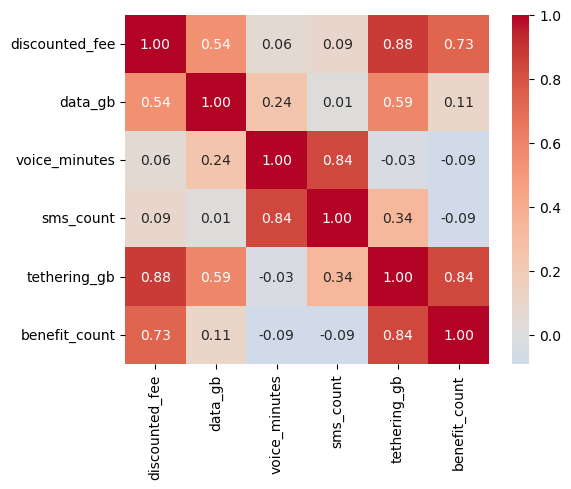

In [49]:
numeric_cols = ["discounted_fee", "data_gb", "voice_minutes", "sms_count", "tethering_gb", "benefit_count"]
corr = plans[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.tight_layout()
plt.show()

## 정리 (섹션 8~17 실행 결과)

- **5G/LTE 가격·데이터 차이가 큼**: 5G 평균 42,953원(데이터 평균 55.5GB) vs LTE 평균
  14,906원(20.2GB) — carrier_type만큼이나 network_gen도 가격을 크게 가른다.
  향후 Plan Matching 스코어링에서 `preferred_network_gen`을 필터/가점으로 쓸 근거.
- **테더링 결측이 큼**: `base_tethering_gb`/`tethering_gb` 64%, `extra_tethering_gb`
  95% 결측 — 대부분 요금제가 테더링 정보를 안 주거나 해당 없음. User Profiling이
  테더링을 필수 슬롯으로 요구하면 안 됨(응답 못 하는 요금제가 대다수).
- **혜택 실부담금(`user_pay_won`)은 98.5% 결측**, `benefit_value_won`과 둘 다 채워진
  건 79/5408건뿐. "혜택 가치"로 스코어링하려면 `benefit_value_won`(채움률 25.5%,
  섹션6)에 의존할 수밖에 없고, 실부담금 기반 비교는 사실상 불가능.
- **이상치/데이터 품질 이슈 2건 발견**:
  - `voice_minutes`가 2000~9997분인데 `voice_unlimited=False`로 분류된 행 28건 —
    사실상 무제한에 가까운데 라벨이 다름. 원본 문구가 "사실상 무제한"류 표현일
    가능성이 높아 `docs/수정이력.md`에 기록 후보.
  - `discounted_fee == 0`인 요금제 11건 — 대부분 LGU+ MVNO 초저가 요금제
    (`monthly_fee` 1,700~28,820원대)라 파싱 오류보다는 실제 프로모션가로 보임.
  - `data_gb` IQR 기준 이상치 480건은 분포 자체가 오른쪽으로 크게 치우쳐서(대부분
    소용량, 소수 대용량) 나온 통계적 결과일 뿐 — 실제 파싱 오류로 보이진 않음.
- MVNO 상위 10개 브랜드 간 `discounted_fee` 평균이 브랜드마다 다르게 갈림(섹션9
  boxplot) — "알뜰폰은 다 저렴하다"가 아니라 브랜드별 가격 포지셔닝이 존재.

기존 섹션1~7의 두 사실(MVNO 무제한 비율 ~50%, 연령조건부=전량 MNO)이
`docs/세그먼트_설계.md` 근거로 쓰인 것처럼, 위 사실들도 다음 단계
(Plan Matching 스코어링 가중치, User Profiling 슬롯 설계)에 참고한다.

# 18. 요금제 시장 공급 구조 분석

지금까지는 컬럼별 결측/이상치를 훑었다. 여기서는 "실제 상품이 어떻게 설계돼 있는가"를
묻는다 - 공급자가 어떤 스펙 구간에 상품을 몰아넣는지, 프로모션가는 얼마나 부풀려지는지.

## 18-1. 데이터 제공량은 어떤 값에 몰려 있는가

무제한 요금제는 GB 개념이 없으므로 `metered`(섹션3에서 정의)만 본다.

In [50]:
metered["data_gb"].value_counts().head(15)

data_gb
15.0     399
10.0     265
11.0     251
7.0      222
100.0    199
5.0      120
1.0       79
6.0       77
20.0      72
3.0       61
95.0      37
200.0     34
150.0     34
110.0     33
30.0      31
Name: count, dtype: int64

## 18-2. 저용량/중용량/대용량 구간 분포

경계는 임의 기준(6GB=일반 소진 후 저속무제한 걸리는 흔한 기준, 100GB=사실상 대용량).

In [51]:
bins = [0, 2, 6, 30, 100, float("inf")]
labels = ["1GB이하", "2~6GB", "6~30GB", "30~100GB", "100GB초과"]
data_tier = pd.cut(metered["data_gb"], bins=bins, labels=labels)
data_tier.value_counts().reindex(labels)

data_gb
1GB이하        174
2~6GB        341
6~30GB      1369
30~100GB     333
100GB초과      168
Name: count, dtype: int64

## 18-3. 기본 데이터 소진 후 QoS(속도제어) 제공 여부

In [52]:
plans["data_throttle_speed"].notna().mean(), plans.groupby("carrier_type")["data_throttle_speed"].apply(lambda s: s.notna().mean())

(np.float64(0.692390139335477),
 carrier_type
 MNO     0.631579
 MVNO    0.707295
 Name: data_throttle_speed, dtype: float64)

## 18-4. QoS 속도는 1/3/5Mbps 중 어디에 몰리는가

In [53]:
plans["data_throttle_speed"].value_counts()

data_throttle_speed
1Mbps      725
3Mbps      523
5Mbps      376
100Kbps    116
400Kbps    111
200Kbps     48
10Mbps      39
Name: count, dtype: int64

## 18-5. 테더링 제공량은 데이터 제공량과 비례하는가

둘 다 채워진 행만(둘 다 결측률이 높음, 섹션11).

In [54]:
both_teth = plans.dropna(subset=["data_gb", "tethering_gb"])
print("상관계수:", both_teth["data_gb"].corr(both_teth["tethering_gb"]))
(both_teth["tethering_gb"] / both_teth["data_gb"]).describe()

상관계수: 0.5915843325420715


count    453.000000
mean       0.697046
std        0.389035
min        0.000000
25%        0.300000
50%        1.000000
75%        1.000000
max        1.100000
dtype: float64

## 18-6. 통화/문자는 대부분 무제한인가

In [55]:
plans[["voice_unlimited", "sms_unlimited"]].mean()

voice_unlimited    0.613791
sms_unlimited      0.597713
dtype: float64

## 18-7. 월정액은 어느 구간에 몰려 있는가

`discounted_fee`(실제 납부액) 기준.

In [56]:
bins = [0, 20000, 40000, 60000, 90000, float("inf")]
labels = ["2만원이하", "2~4만원", "4~6만원", "6~9만원", "9만원초과"]
fee_tier = pd.cut(plans["discounted_fee"], bins=bins, labels=labels)
fee_tier.value_counts().reindex(labels)

discounted_fee
2만원이하    1537
2~4만원     723
4~6만원     190
6~9만원     206
9만원초과      73
Name: count, dtype: int64

## 18-8. 프로모션 종료 후 가격이 얼마나 오르는가

MVNO는 `monthly_fee`=프로모션 종료 후 정상가, `discounted_fee`=현재 납부액
(README/컬럼 명세서 기준). 프로모션 기간이 있는 상품만(`discount_period_months` 존재).

In [57]:
promo = plans.loc[(plans["carrier_type"] == "MVNO") & plans["discount_period_months"].notna() & (plans["discounted_fee"] > 0)].copy()
promo["hike_ratio"] = (promo["monthly_fee"] - promo["discounted_fee"]) / promo["discounted_fee"]
print(len(promo), "개 프로모션 상품 (discounted_fee=0 제외)")
promo["hike_ratio"].describe()

1525 개 프로모션 상품 (discounted_fee=0 제외)


count    1525.000000
mean      134.278894
std       487.913543
min         0.040816
25%         0.728571
50%         1.363158
75%         3.000000
max      3629.000000
Name: hike_ratio, dtype: float64

## 18-9. 특정 조건을 충족하는 요금제가 실제로 몇 개인가

예시: 데이터 무제한 + 통화 무제한 + 월 5만원 이하(실납부가). 조건은 바꿔서 재사용.

In [58]:
cond = plans["data_unlimited"].fillna(False) & plans["voice_unlimited"].fillna(False) & (plans["discounted_fee"] <= 50000)
print(cond.sum(), "개 /", len(plans), "행 전체")
plans.loc[cond, ["plan_id", "carrier_type", "host_mno", "discounted_fee", "data_gb"]].head(10)

8 개 / 2799 행 전체


,plan_id,carrier_type,host_mno,discounted_fee,data_gb
511,29062,MNO,LGU+,19000.0,NaN
888,33130,MVNO,LGU+,17060.0,NaN
903,27775,MVNO,LGU+,12730.0,NaN
1069,27774,MVNO,LGU+,17060.0,NaN
1635,27776,MVNO,LGU+,6060.0,NaN
1654,27750,MVNO,LGU+,9940.0,NaN
1691,27749,MVNO,LGU+,7840.0,NaN
1989,32358,MVNO,SKT,20900.0,NaN


## 정리 (섹션 18: 공급 구조)

> 2026-08-06 모요 카드 파싱 버그(월 라벨 없는 "무제한"/"매일 NGB"/"데이터 제공안함"
> 형식 95건 누락) 수정 후 재실행 - 이 절의 숫자는 그 수정이 반영된 값이다.

- **데이터 제공량은 정수 GB 몇 개 값에 강하게 몰림**: 15GB(399건)·10GB(265)·11GB(251)·
  7GB(222)·100GB(199)가 상위 5개. 구간별로는 6~30GB가 정량제 요금제의 57.4%(1,369건)로
  압도적 다수 - "중용량"이 시장의 기본값이고 대용량(100GB 초과)은 7.0%(168건)뿐.
- **QoS(소진 후 속도제어) 제공률 69.2%**, MNO(63.2%)보다 MVNO(70.7%)가 오히려 높음 -
  MVNO가 무제한을 "소진 후 저속 무제한" 구조로 많이 설계한다는 뜻.
- **QoS 속도는 저속에 몰림**: 1Mbps(725) > 3Mbps(523) > 5Mbps(376) 순. 100~400Kbps급
  초저속 티어도 275건 있어 "QoS=쓸만한 속도"로 뭉뚱그리면 안 됨 - 속도값 자체가
  요금제 등급을 가르는 스펙.
- **테더링은 데이터와 약하게만 비례**(상관계수 0.59). `tethering_gb / data_gb` 비율의
  중앙값은 1.0(데이터 전량 테더링 가능)이지만 25%는 0.3 이하 - "데이터 많으면 테더링도
  많다"는 절반만 맞는 얘기.
- **통화/문자 무제한은 "대부분"이 아니라 약 61%**(음성 61.4%, 문자 59.8%)지만 **MNO/MVNO
  격차가 크다**(섹션4) - MNO는 음성 95.5%·문자 94.2%로 사실상 다 무제한인 반면 MVNO는
  53.0%·51.3%로 절반 수준. "무제한이 기본"은 MNO에만 해당하는 얘기다.
- **월정액은 2만원 이하에 56.3%가 몰림**(1,537/2,729) - MVNO 저가 요금제가 물량으로
  깔려 있어서다. 6만원 초과는 2.7%(73건)뿐.
- **MVNO 프로모션 종료 후 인상폭이 큼**: 중앙값 136% 인상(즉 정상가가 현재 납부액의
  2.36배), 상위 25%는 300% 이상. `max` 362,900%는 `discounted_fee`가 극소값(원 단위
  오류 추정)인 이상치라 액면 그대로 쓰면 안 됨 - 인상률 통계는 median 기준으로 봐야
  한다.
- **"데이터 무제한 + 통화 무제한 + 5만원 이하" 조건을 동시에 만족하는 요금제는
  2,799행 중 8건**(모요 파싱 버그 수정 전엔 1건으로 보였다 - "무제한" 라벨이 없는
  카드가 누락돼 있었을 뿐, 실제로는 8배 더 있었다). 그래도 전체의 0.3%뿐이라 "완전
  무제한 + 저가"가 희귀한 조합이라는 결론 자체는 유지된다.

**Plan Matching/스코어링에 주는 시사점**: (1) 데이터 구간은 6~30GB를 기준선으로
잡고 위아래 이탈을 가점/감점 요인으로 쓸 것, (2) QoS 속도(1/3/5Mbps)는 무시하지 말고
"무제한" 안에서도 등급을 나눌 것, (3) 통화/문자 무제한 여부는 `carrier_type`과 함께
봐야 한다 - MVNO 사용자에게 "무제한 아니면 이상하다"는 가정으로 점수를 매기면 안 됨,
(4) MVNO 가격은 `discounted_fee` 그대로 쓰되 프로모션 종료 시점 리스크를 별도
신호로 안내할 필요가 있음(특히 인상률 상위 25% 사용자).
